# Pollinator Classifier — Full Pipeline & Comparison
Trains both models sequentially, saves histories automatically,
then generates all comparison visuals from real results.

| Section | What happens |
|---|---|
| **Part A** | Shared setup — Drive, imports, datasets |
| **Part B** | Baseline CNN — build, train, evaluate, save |
| **Part C** | Improved EfficientNetV2S — build, train (2 phases), evaluate, save |
| **Part D** | Comparison visuals — all charts from real numbers |

---
## Part A — Shared Setup

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print('Num GPUs:', len(tf.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs: 1


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('TF version:', tf.__version__)

TF version: 2.20.0


In [4]:
# ── Config — edit base_path if your folder is named differently ───────────────
base_path  = '/content/drive/MyDrive/Colab Notebooks/pollinators/'
IMG_SIZE   = (224, 224)
AUTOTUNE   = tf.data.AUTOTUNE
SAVE_FIGS  = True

import os
if SAVE_FIGS:
    os.makedirs(base_path + 'comparison_figs/', exist_ok=True)

In [5]:
# ── Load raw datasets (shared by both models) ─────────────────────────────────
# Baseline uses batch=32, Improved uses batch=64 — we load both here
full_ds_32 = tf.keras.utils.image_dataset_from_directory(
    base_path + 'train',
    image_size=IMG_SIZE, batch_size=32, shuffle=True, seed=42
)
full_ds_64 = tf.keras.utils.image_dataset_from_directory(
    base_path + 'train',
    image_size=IMG_SIZE, batch_size=64, shuffle=True, seed=42
)
test_ds_raw_32 = tf.keras.utils.image_dataset_from_directory(
    base_path + 'test', image_size=IMG_SIZE, batch_size=32
)
test_ds_raw_64 = tf.keras.utils.image_dataset_from_directory(
    base_path + 'test', image_size=IMG_SIZE, batch_size=64
)

class_names = full_ds_32.class_names
num_classes  = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

# 80/20 train/val splits
def split_ds(full_ds):
    total  = len(full_ds)
    n_train = int(0.8 * total)
    return full_ds.take(n_train), full_ds.skip(n_train), n_train, total - n_train

train_raw_32, val_raw_32, tr32, vl32 = split_ds(full_ds_32)
train_raw_64, val_raw_64, tr64, vl64 = split_ds(full_ds_64)
print(f'Batch=32 → train: {tr32}  val: {vl32}')
print(f'Batch=64 → train: {tr64}  val: {vl64}')

Found 12594 files belonging to 100 classes.
Found 12594 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Found 500 files belonging to 100 classes.
Classes (100): ['ADONIS', 'AFRICAN GIANT SWALLOWTAIL', 'AMERICAN SNOOT', 'AN 88', 'APPOLLO', 'ARCIGERA FLOWER MOTH', 'ATALA', 'ATLAS MOTH', 'BANDED ORANGE HELICONIAN', 'BANDED PEACOCK', 'BANDED TIGER MOTH', 'BECKERS WHITE', 'BIRD CHERRY ERMINE MOTH', 'BLACK HAIRSTREAK', 'BLUE MORPHO', 'BLUE SPOTTED CROW', 'BROOKES BIRDWING', 'BROWN ARGUS', 'BROWN SIPROETA', 'CABBAGE WHITE', 'CAIRNS BIRDWING', 'CHALK HILL BLUE', 'CHECQUERED SKIPPER', 'CHESTNUT', 'CINNABAR MOTH', 'CLEARWING MOTH', 'CLEOPATRA', 'CLODIUS PARNASSIAN', 'CLOUDED SULPHUR', 'COMET MOTH', 'COMMON BANDED AWL', 'COMMON WOOD-NYMPH', 'COPPER TAIL', 'CRECENT', 'CRIMSON PATCH', 'DANAID EGGFLY', 'EASTERN COMA', 'EASTERN DAPPLE WHITE', 'EASTERN PINE ELFIN', 'ELBOWED PIERROT', 'EMPEROR GUM MOTH', 'GARDEN TIGER MOTH', 'GIANT LEOPARD MOTH', 'GLITTERING SAPPHIRE', 'GOLD B

---
## Part B — Baseline CNN (from scratch)

In [6]:
# ── B1. Normalization pipeline (baseline rescales to [0,1]) ───────────────────
norm = layers.Rescaling(1./255)

train_ds_a = train_raw_32.map(lambda x, y: (norm(x), y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds_a   = val_raw_32.map(lambda x, y: (norm(x), y)).cache().prefetch(AUTOTUNE)
test_ds_a  = test_ds_raw_32.map(lambda x, y: (norm(x), y)).cache().prefetch(AUTOTUNE)

In [7]:
# ── B2. Data augmentation ─────────────────────────────────────────────────────
aug_a = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
], name='augmentation_baseline')

In [8]:
# ── B3. Build model ───────────────────────────────────────────────────────────
model_a = models.Sequential([
    aug_a,
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    # Block 4
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    # Block 5
    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.005)),
    layers.Dropout(0.6),
    layers.Dense(num_classes, activation='softmax')
])

model_a.build(input_shape=(None, 224, 224, 3))
model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation_baseline           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,729,572 (6.60 MB)

 Trainable params: 1,727,588 (6.59 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [9]:
# ── B4. Compile ───────────────────────────────────────────────────────────────
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_a = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

In [10]:
# ── B5. Train ─────────────────────────────────────────────────────────────────
print('Training Baseline CNN...')
history_a = model_a.fit(
    train_ds_a,
    validation_data=val_ds_a,
    epochs=50,
    callbacks=callbacks_a
)

Training Baseline CNN...
Epoch 1/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 753s 540ms/step - accuracy: 0.0627 - loss: 5.9579 - val_accuracy: 0.0251 - val_loss: 6.5954 - learning_rate: 1.0000e-04
Epoch 2/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.1394 - loss: 5.2922 - val_accuracy: 0.2430 - val_loss: 4.8509 - learning_rate: 1.0000e-04
Epoch 3/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.1848 - loss: 4.8502 - val_accuracy: 0.2959 - val_loss: 4.3441 - learning_rate: 1.0000e-04
Epoch 4/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.2442 - loss: 4.4501 - val_accuracy: 0.2928 - val_loss: 4.2292 - learning_rate: 1.0000e-04
Epoch 5/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.2997 - loss: 4.0979 - val_accuracy: 0.3719 - val_loss: 3.8427 - learning_rate: 1.0000e-04
Epoch 6/50
315/315 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.3378 - loss: 3.8153 - val_accuracy: 0.3902 - val_loss: 3.6630 - learning_rate: 1.0000e-04
Epoch 7/50
315/315 ━━━━━━

In [11]:
# ── B6. Evaluate + Save ───────────────────────────────────────────────────────
print('\n=== BASELINE — TEST SET ===')
loss_a, acc_a = model_a.evaluate(test_ds_a)
print(f'Test accuracy: {acc_a:.4f}  |  Test loss: {loss_a:.4f}')

model_a.save(base_path + 'pollinator_model.keras')
pickle.dump(history_a.history,
            open(base_path + 'history_baseline.pkl', 'wb'))
print('Model + history saved.')


=== BASELINE — TEST SET ===
16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.8580 - loss: 0.7481
Test accuracy: 0.8580  |  Test loss: 0.7481
Model + history saved.


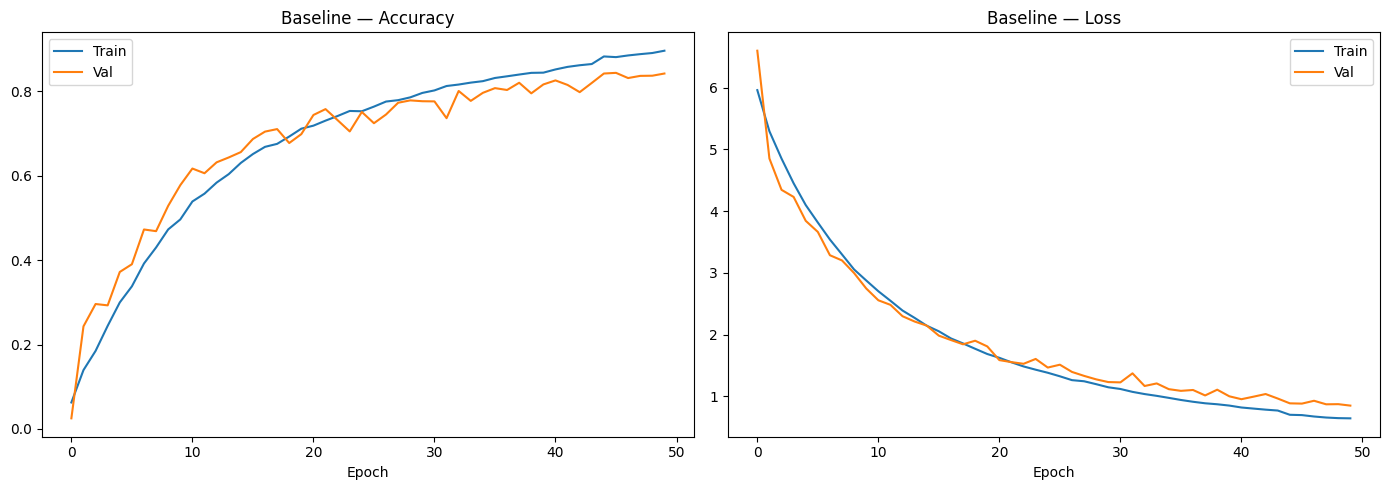

In [12]:
# ── B7. Quick training plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_a.history['accuracy'],     label='Train')
ax1.plot(history_a.history['val_accuracy'], label='Val')
ax1.set_title('Baseline — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history_a.history['loss'],     label='Train')
ax2.plot(history_a.history['val_loss'], label='Val')
ax2.set_title('Baseline — Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(base_path + 'training_history_baseline.png', dpi=150)
plt.show()

---
## Part C — Improved Model (EfficientNetV2S + Transfer Learning)

In [13]:
# ── C1. Pipeline — EfficientNet expects raw [0,255] ───────────────────────────
train_ds_b = train_raw_64.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds_b   = val_raw_64.cache().prefetch(AUTOTUNE)
test_ds_b  = test_ds_raw_64.cache().prefetch(AUTOTUNE)

In [14]:
# ── C2. Augmentation (+ RandomBrightness vs baseline) ────────────────────────
aug_b = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),   # CHANGED: added
], name='augmentation_improved')

In [15]:
# ── C3. Build model — EfficientNetV2S backbone (frozen for phase 1) ───────────
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False, weights='imagenet', input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = aug_b(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_b = tf.keras.Model(inputs, outputs)
model_b.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation_improved           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,684,996 (78.91 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [16]:
# ── C4. Phase 1 — train head only (backbone frozen) ──────────────────────────
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_b = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1)
]

print('Phase 1 — training head only...')
history_phase1 = model_b.fit(
    train_ds_b, validation_data=val_ds_b,
    epochs=10, callbacks=callbacks_b
)

Phase 1 — training head only...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 66s 186ms/step - accuracy: 0.3216 - loss: 3.3209 - val_accuracy: 0.5841 - val_loss: 2.0973 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.6064 - loss: 1.9137 - val_accuracy: 0.7518 - val_loss: 1.4927 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6964 - loss: 1.5720 - val_accuracy: 0.7942 - val_loss: 1.2906 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7362 - loss: 1.3985 - val_accuracy: 0.8162 - val_loss: 1.1603 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7572 - loss: 1.3005 - val_accuracy: 0.8339 - val_loss: 1.0812 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.7770 - loss: 1.2114 - val_accuracy: 0.8370 - val_loss: 1.0600 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s

In [17]:
# ── C5. Phase 2 — unfreeze top 50 layers and fine-tune ───────────────────────
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

print(f'Trainable layers: {sum(1 for l in model_b.layers if l.trainable)}')

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2 — fine-tuning top 50 layers...')
history_phase2 = model_b.fit(
    train_ds_b, validation_data=val_ds_b,
    epochs=50, callbacks=callbacks_b
)

Trainable layers: 7
Phase 2 — fine-tuning top 50 layers...
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 46s 111ms/step - accuracy: 0.8126 - loss: 1.2371 - val_accuracy: 0.8680 - val_loss: 0.9726 - learning_rate: 1.0000e-05
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8229 - loss: 1.1306 - val_accuracy: 0.8767 - val_loss: 0.9249 - learning_rate: 1.0000e-05
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8379 - loss: 1.0583 - val_accuracy: 0.8782 - val_loss: 0.8920 - learning_rate: 1.0000e-05
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8431 - loss: 1.0171 - val_accuracy: 0.8849 - val_loss: 0.8679 - learning_rate: 1.0000e-05
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8439 - loss: 0.9798 - val_accuracy: 0.8892 - val_loss: 0.8347 - learning_rate: 1.0000e-05
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.8555 - loss: 0.9399 - val_accuracy: 0.8896 - val_loss: 0.8290 - learning_rate: 1.0

In [18]:
# ── C6. Evaluate + Save ───────────────────────────────────────────────────────
print('\n=== IMPROVED — TEST SET ===')
loss_b, acc_b = model_b.evaluate(test_ds_b)
print(f'Test accuracy: {acc_b:.4f}  |  Test loss: {loss_b:.4f}')

# Combine both phase histories into one dict and save
phase1_len = len(history_phase1.history['accuracy'])
hist_b_combined = {
    'accuracy':     history_phase1.history['accuracy']     + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss':         history_phase1.history['loss']         + history_phase2.history['loss'],
    'val_loss':     history_phase1.history['val_loss']     + history_phase2.history['val_loss'],
    'phase1_epochs': phase1_len
}

model_b.save(base_path + 'pollinator_model_v2.keras')
pickle.dump(hist_b_combined,
            open(base_path + 'history_improved.pkl', 'wb'))
print('Model + history saved.')


=== IMPROVED — TEST SET ===
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9340 - loss: 0.5328
Test accuracy: 0.9340  |  Test loss: 0.5328
Model + history saved.


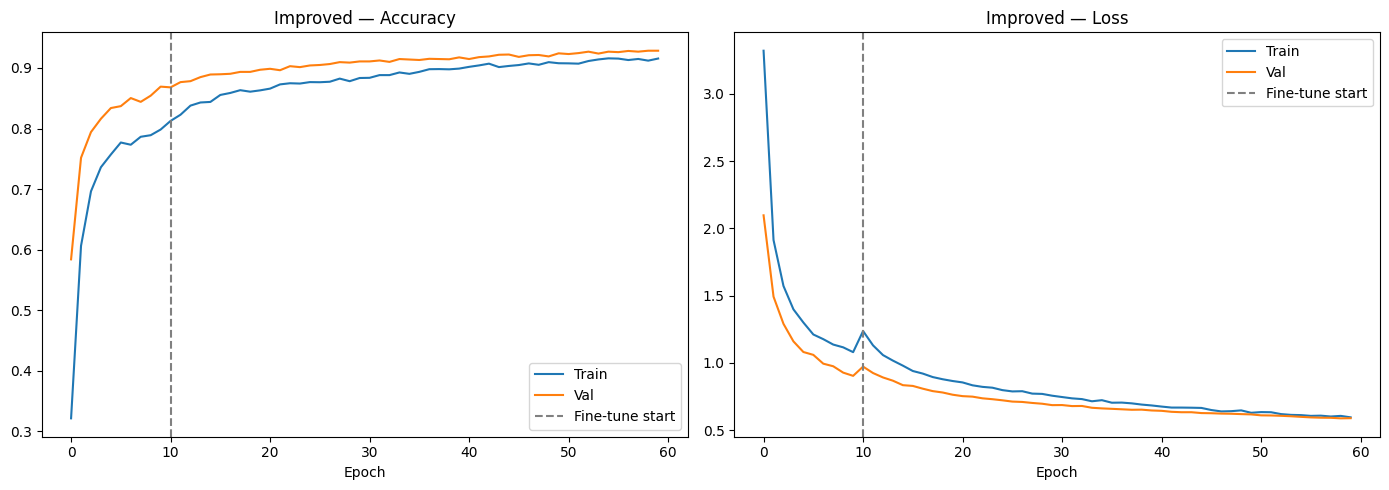

In [19]:
# ── C7. Quick training plot (both phases) ─────────────────────────────────────
acc      = hist_b_combined['accuracy']
val_acc  = hist_b_combined['val_accuracy']
loss_c   = hist_b_combined['loss']
val_loss = hist_b_combined['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(acc, label='Train'); ax1.plot(val_acc, label='Val')
ax1.axvline(phase1_len, color='gray', ls='--', label='Fine-tune start')
ax1.set_title('Improved — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(loss_c, label='Train'); ax2.plot(val_loss, label='Val')
ax2.axvline(phase1_len, color='gray', ls='--', label='Fine-tune start')
ax2.set_title('Improved — Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(base_path + 'training_history_improved.png', dpi=150)
plt.show()

---
## Part D — Comparison Visuals
All charts are generated from the real training and test results above.

In [20]:
# ── D0. Style ─────────────────────────────────────────────────────────────────
BLUE   = '#378ADD'
TEAL   = '#1D9E75'
BLUE_L = '#B5D4F4'
TEAL_L = '#9FE1CB'
BG     = '#F8F8F6'
DARK   = '#2C2C2A'
GRAY   = '#888780'
LGRAY  = '#D3D1C7'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.spines.left': False, 'axes.spines.bottom': False,
    'axes.grid': True, 'grid.alpha': 0.35, 'grid.linewidth': 0.5,
    'axes.facecolor': BG, 'figure.facecolor': 'white',
})

def savefig(name):
    if SAVE_FIGS:
        plt.savefig(base_path + 'comparison_figs/' + name, dpi=150, bbox_inches='tight')

# Pull val_accuracy from histories
val_acc_a = history_a.history['val_accuracy'][-1]
val_acc_b = hist_b_combined['val_accuracy'][-1]

params_a = model_a.count_params() / 1e6
params_b = model_b.count_params() / 1e6

print(f'Baseline  — test acc: {acc_a:.4f}  val acc: {val_acc_a:.4f}  params: {params_a:.1f}M')
print(f'Improved  — test acc: {acc_b:.4f}  val acc: {val_acc_b:.4f}  params: {params_b:.1f}M')
print(f'Delta     — {acc_b - acc_a:+.4f} ({(acc_b-acc_a)*100:+.2f} pp)')

Baseline  — test acc: 0.8580  val acc: 0.8421  params: 1.7M
Improved  — test acc: 0.9340  val acc: 0.9285  params: 20.7M
Delta     — +0.0760 (+7.60 pp)


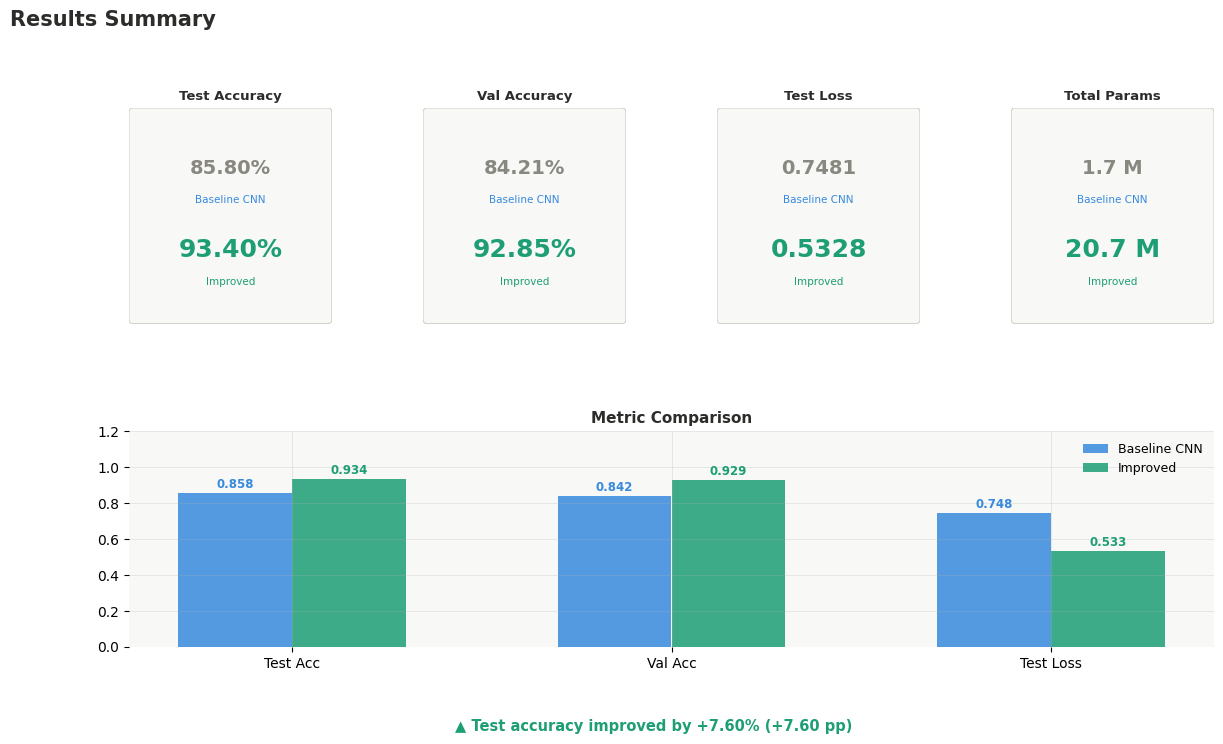

In [21]:
# ── D1. Results Dashboard ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.45)

card_data = [
    ('Test Accuracy', [acc_a,      acc_b],      '{:.2%}', 'higher'),
    ('Val Accuracy',  [val_acc_a,  val_acc_b],  '{:.2%}', 'higher'),
    ('Test Loss',     [loss_a,     loss_b],     '{:.4f}', 'lower'),
    ('Total Params',  [params_a,   params_b],   '{:.1f} M', 'higher'),
]
model_names = ['Baseline CNN', 'Improved']
colors_m    = [BLUE, TEAL]

for j, (label, vals, fmt, better) in enumerate(card_data):
    ax = fig.add_subplot(gs[0, j])
    ax.axis('off')
    best = max(vals) if better == 'higher' else min(vals)
    ax.add_patch(mpatches.FancyBboxPatch((0.02,0.02), 0.96, 0.96,
        boxstyle='round,pad=0.02', fc=BG, ec=LGRAY, lw=0.8,
        transform=ax.transAxes))
    for k, (m, v, c) in enumerate(zip(model_names, vals, colors_m)):
        yoff = 0.72 - k*0.38
        ax.text(0.5, yoff, fmt.format(v), transform=ax.transAxes,
                ha='center', va='center',
                fontsize=18 if v==best else 14,
                fontweight='bold', color=c if v==best else GRAY)
        ax.text(0.5, yoff-0.16, m, transform=ax.transAxes,
                ha='center', fontsize=7.5, color=c)
    ax.set_title(label, fontsize=9.5, fontweight='bold', color=DARK)

ax2 = fig.add_subplot(gs[1, :])
ax2.set_facecolor(BG)
bar_data = [('Test Acc', [acc_a, acc_b]),
            ('Val Acc',  [val_acc_a, val_acc_b]),
            ('Test Loss',[loss_a, loss_b])]
x, w = np.arange(3), 0.3
for k, (mname, c) in enumerate(zip(model_names, colors_m)):
    vals = [d[1][k] for d in bar_data]
    bars = ax2.bar(x + k*w - w/2, vals, w, color=c, alpha=0.85, label=mname)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8.5,
                 fontweight='bold', color=c)
ax2.set_xticks(x)
ax2.set_xticklabels([d[0] for d in bar_data], fontsize=10)
ax2.set_ylim(0, 1.2)
ax2.legend(frameon=False, fontsize=9)
ax2.set_title('Metric Comparison', fontsize=11, fontweight='bold', color=DARK)
for sp in ax2.spines.values(): sp.set_visible(False)

delta = acc_b - acc_a
fig.text(0.5, -0.01, f'▲ Test accuracy improved by {delta:+.2%} ({delta*100:+.2f} pp)',
         ha='center', fontsize=10.5, fontweight='bold', color=TEAL)
fig.suptitle('Results Summary', fontsize=15, fontweight='bold',
             color=DARK, x=0.04, ha='left', y=1.02)
savefig('01_results_dashboard.png')
plt.show()

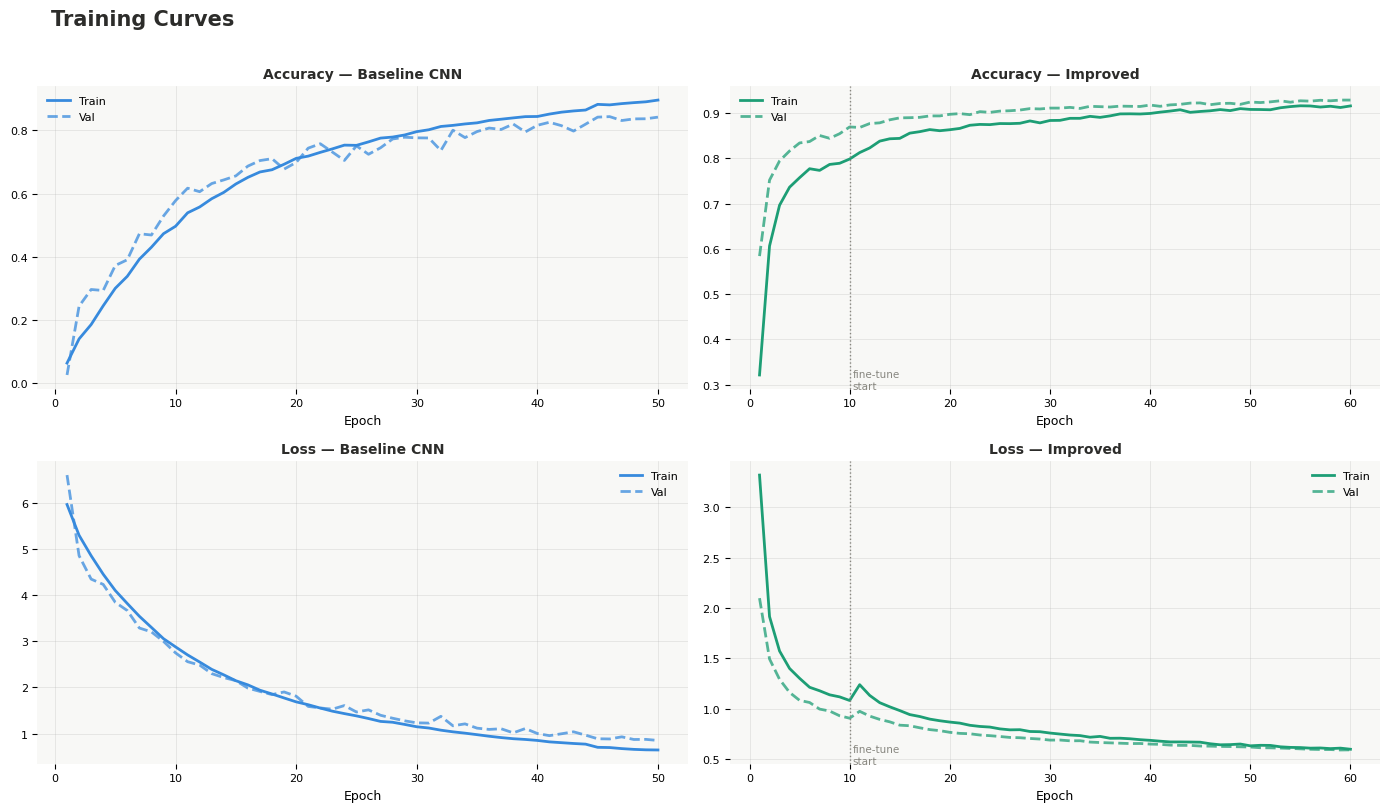

In [22]:
# ── D2. Training Curves ───────────────────────────────────────────────────────
hist_a_dict = history_a.history
ft_epoch    = hist_b_combined['phase1_epochs']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def plot_curve(ax, hist, color, title, metric, ft_start=None):
    train = hist.get(metric, [])
    val   = hist.get('val_' + metric, [])
    ep    = np.arange(1, len(train)+1)
    ax.set_facecolor(BG)
    if len(train): ax.plot(ep, train, color=color, lw=2, label='Train')
    if len(val):   ax.plot(np.arange(1,len(val)+1), val, color=color,
                           lw=2, ls='--', alpha=0.75, label='Val')
    if ft_start:
        ax.axvline(ft_start, color=GRAY, lw=1, ls=':')
        ax.text(ft_start+0.3, ax.get_ylim()[0], 'fine-tune\nstart',
                fontsize=7.5, color=GRAY)
    ax.set_title(title, fontsize=10, fontweight='bold', color=DARK)
    ax.set_xlabel('Epoch', fontsize=9)
    ax.legend(fontsize=8, frameon=False)
    ax.tick_params(labelsize=8)
    for sp in ax.spines.values(): sp.set_visible(False)

plot_curve(axes[0,0], hist_a_dict,      BLUE, 'Accuracy — Baseline CNN', 'accuracy')
plot_curve(axes[0,1], hist_b_combined,  TEAL, 'Accuracy — Improved',     'accuracy', ft_start=ft_epoch)
plot_curve(axes[1,0], hist_a_dict,      BLUE, 'Loss — Baseline CNN',     'loss')
plot_curve(axes[1,1], hist_b_combined,  TEAL, 'Loss — Improved',         'loss',     ft_start=ft_epoch)

fig.suptitle('Training Curves', fontsize=15, fontweight='bold',
             color=DARK, x=0.04, ha='left', y=1.01)
plt.tight_layout()
savefig('02_training_curves.png')
plt.show()

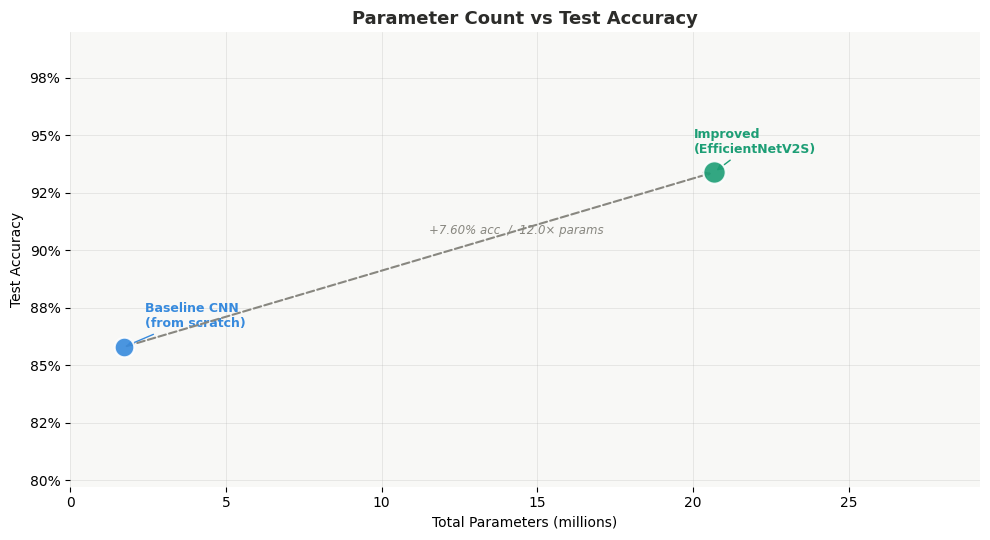

In [23]:
# ── D3. Parameter Count vs Accuracy ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.set_facecolor(BG)
for sp in ax.spines.values(): sp.set_visible(False)

for name, p, a, c, ms in [
    ('Baseline CNN\n(from scratch)', params_a, acc_a, BLUE, 200),
    ('Improved\n(EfficientNetV2S)',  params_b, acc_b, TEAL, 260),
]:
    ax.scatter(p, a, s=ms, color=c, alpha=0.9, zorder=4, edgecolors='white', lw=1.5)
    ax.annotate(name, (p, a), xytext=(15 if p < (params_a+params_b)/2 else -15, 14),
                textcoords='offset points', fontsize=9, fontweight='bold', color=c,
                arrowprops=dict(arrowstyle='->', color=c, lw=1))

ax.annotate('', xy=(params_b, acc_b), xytext=(params_a, acc_a),
    arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5, linestyle='dashed'))
ax.text((params_a+params_b)/2+0.3, (acc_a+acc_b)/2+0.01,
        f'{acc_b-acc_a:+.2%} acc  /  {params_b/params_a:.1f}× params',
        ha='left', va='bottom', fontsize=8.5, color=GRAY, style='italic')

ax.set_xlabel('Total Parameters (millions)', fontsize=10)
ax.set_ylabel('Test Accuracy', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0%}'))
pad = max(params_b-params_a, 1)*0.15
ax.set_xlim(max(0, params_a-pad*2), params_b+pad*3)
rng = abs(acc_b-acc_a)
ax.set_ylim(min(acc_a,acc_b)-rng*0.8, max(acc_a,acc_b)+rng*0.8)
ax.set_title('Parameter Count vs Test Accuracy', fontsize=13,
             fontweight='bold', color=DARK)
plt.tight_layout()
savefig('03_param_accuracy.png')
plt.show()

In [24]:
# ── D4. Collect predictions (used by all remaining cells) ─────────────────────
from sklearn.metrics import classification_report, precision_recall_fscore_support

def get_preds(model, ds):
    y_true, y_pred = [], []
    for imgs, labels in ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

print('Getting predictions — Baseline...')
yt_a, yp_a = get_preds(model_a, test_ds_a)
print('Getting predictions — Improved...')
yt_b, yp_b = get_preds(model_b, test_ds_b)

report_a = classification_report(yt_a, yp_a, target_names=class_names, output_dict=True, zero_division=0)
report_b = classification_report(yt_b, yp_b, target_names=class_names, output_dict=True, zero_division=0)
prec_a, rec_a, f1_a, _ = precision_recall_fscore_support(yt_a, yp_a, labels=range(num_classes), zero_division=0)
prec_b, rec_b, f1_b, _ = precision_recall_fscore_support(yt_b, yp_b, labels=range(num_classes), zero_division=0)
print('Done.')

Getting predictions — Baseline...
Getting predictions — Improved...
Done.


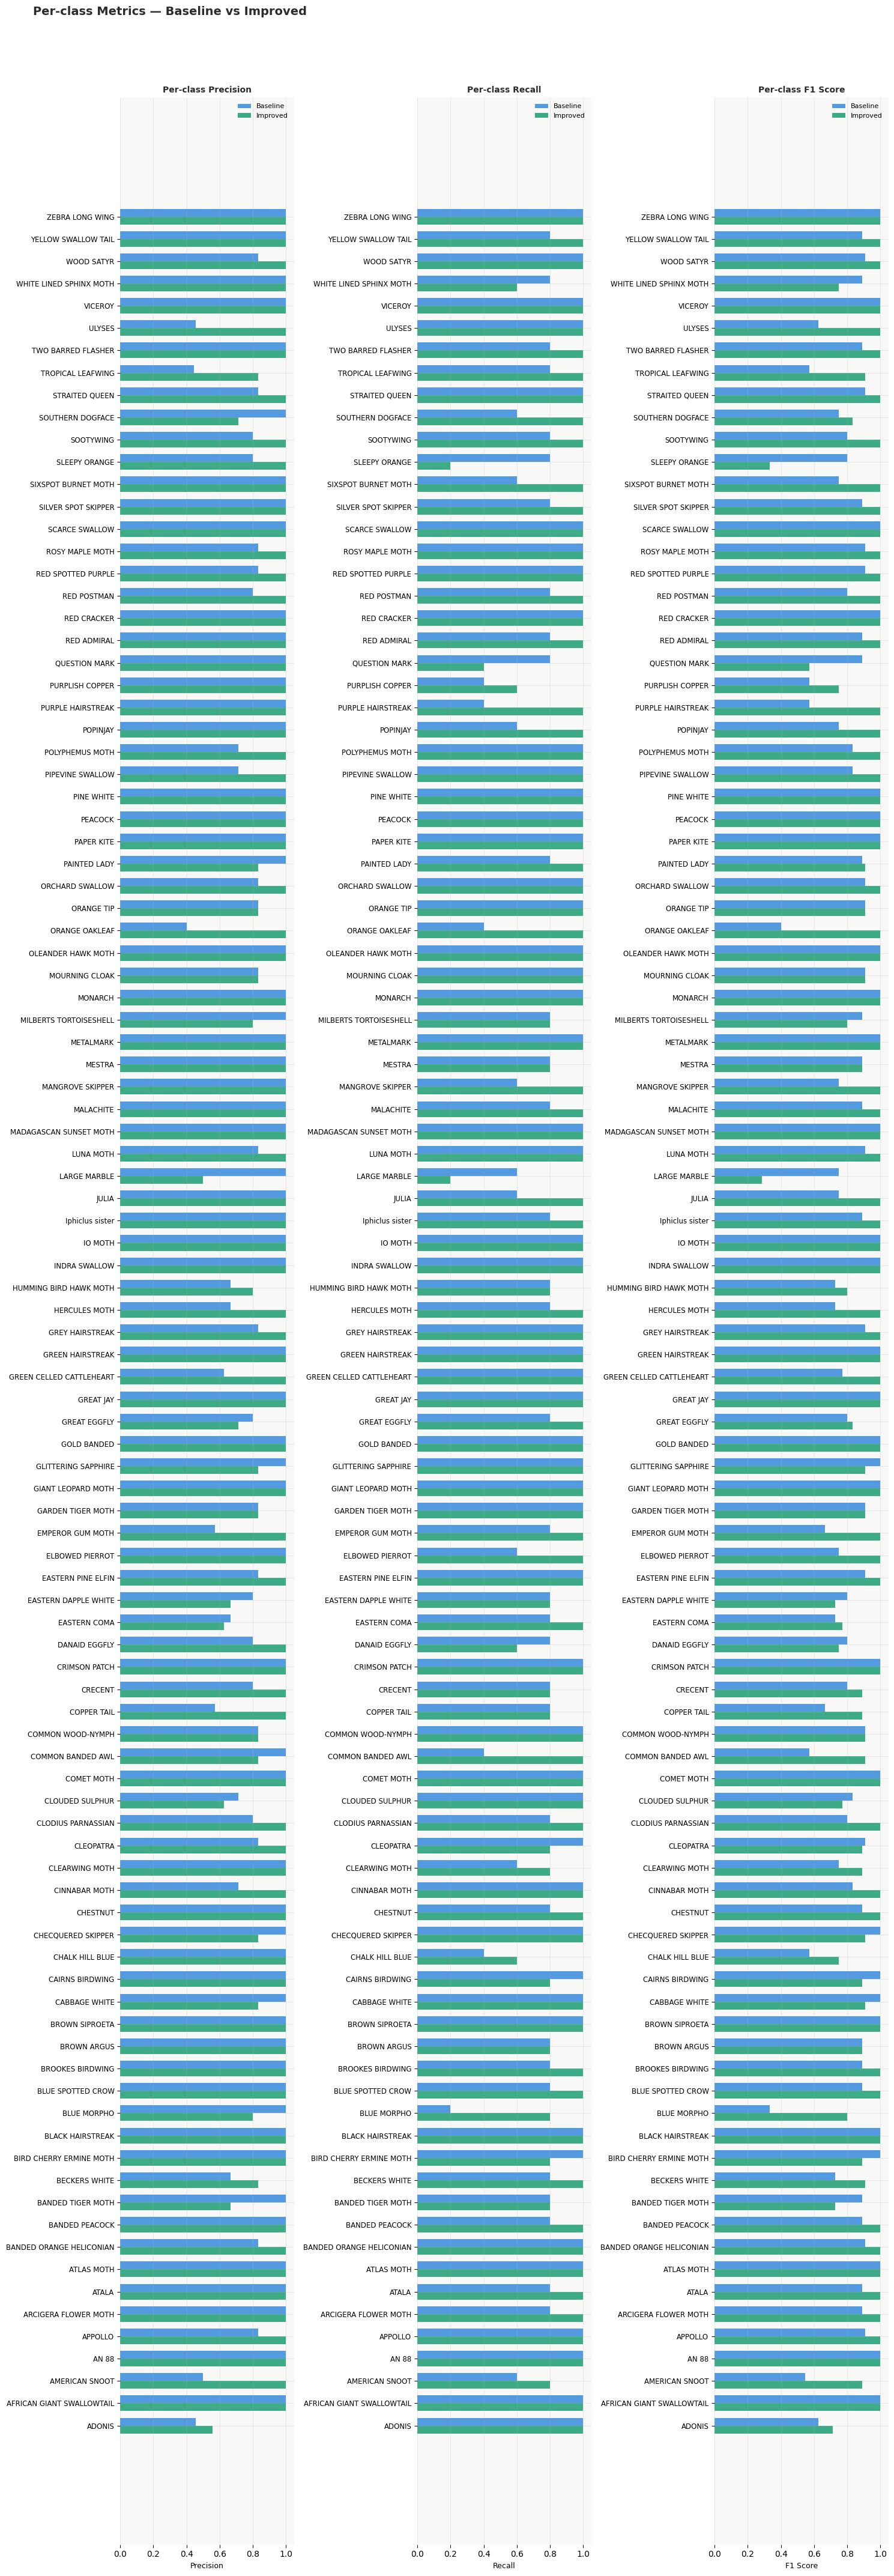

In [25]:
# ── D5. Per-class Precision / Recall / F1 ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, max(4, num_classes*0.4+2)))
y_pos, h = np.arange(num_classes), 0.35

for ax, (metric, va, vb) in zip(axes, [('Precision',prec_a,prec_b),
                                         ('Recall',   rec_a, rec_b),
                                         ('F1 Score', f1_a,  f1_b)]):
    ax.set_facecolor(BG)
    ax.barh(y_pos+h/2, va, h, color=BLUE, alpha=0.85, label='Baseline')
    ax.barh(y_pos-h/2, vb, h, color=TEAL, alpha=0.85, label='Improved')
    ax.set_yticks(y_pos); ax.set_yticklabels(class_names, fontsize=8.5)
    ax.set_xlim(0, 1.05); ax.set_xlabel(metric, fontsize=9)
    ax.set_title(f'Per-class {metric}', fontsize=10, fontweight='bold', color=DARK)
    ax.legend(fontsize=8, frameon=False)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle('Per-class Metrics — Baseline vs Improved', fontsize=14,
             fontweight='bold', color=DARK, x=0.04, ha='left', y=1.02)
plt.tight_layout()
savefig('04_per_class.png')
plt.show()

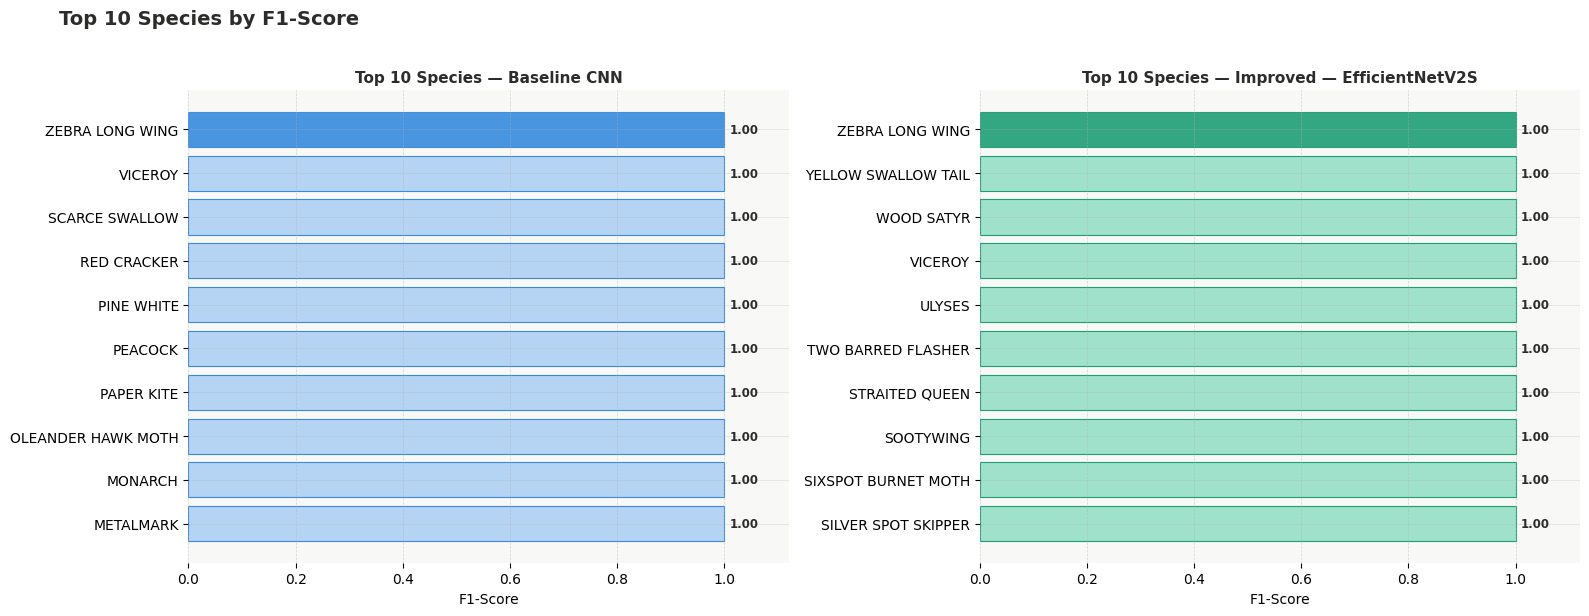

In [26]:
# ── D6. Top 10 Species by F1-Score ────────────────────────────────────────────
def top10_f1(report, names):
    perf = [(s, report[s]['f1-score']) for s in names if s in report]
    perf.sort(key=lambda x: x[1])
    return perf[-10:]

best_a = top10_f1(report_a, class_names)
best_b = top10_f1(report_b, class_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, best, color, lcolor, label in [
    (axes[0], best_a, BLUE, BLUE_L, 'Baseline CNN'),
    (axes[1], best_b, TEAL, TEAL_L, 'Improved — EfficientNetV2S'),
]:
    names_p  = [x[0] for x in best]
    scores_p = [x[1] for x in best]
    ax.set_facecolor(BG)
    bars = ax.barh(names_p, scores_p, color=lcolor, edgecolor=color, linewidth=0.8)
    bars[-1].set_facecolor(color); bars[-1].set_alpha(0.9)
    for bar in bars:
        w = bar.get_width()
        ax.text(w+0.01, bar.get_y()+bar.get_height()/2,
                f'{w:.2f}', va='center', fontsize=8.5, color=DARK, fontweight='bold')
    ax.set_xlabel('F1-Score', fontsize=10); ax.set_xlim(0, 1.12)
    ax.set_title(f'Top 10 Species — {label}', fontsize=11, fontweight='bold', color=DARK)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle('Top 10 Species by F1-Score', fontsize=14,
             fontweight='bold', color=DARK, x=0.04, ha='left', y=1.02)
plt.tight_layout()
savefig('05_top10_species.png')
plt.show()

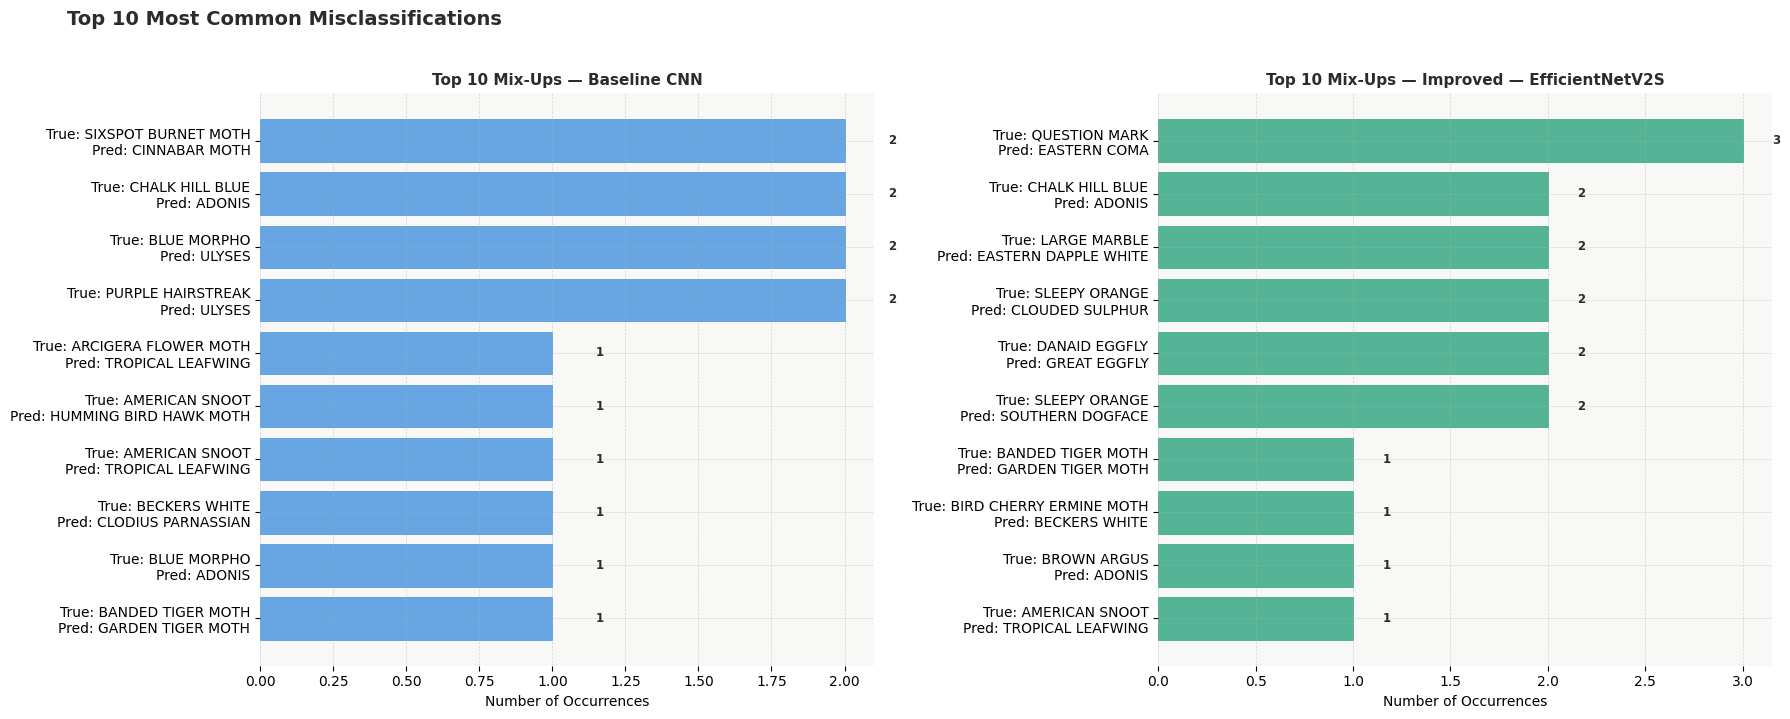

In [27]:
# ── D7. Top 10 Most Common Mix-Ups ────────────────────────────────────────────
def top10_mixups(y_true, y_pred, names, n=10):
    df = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
    df = df[df['Actual'] != df['Predicted']]
    df['Actual']    = df['Actual'].map(lambda x: names[x])
    df['Predicted'] = df['Predicted'].map(lambda x: names[x])
    top    = df.value_counts().head(n)
    labels = [f"True: {a}\nPred: {p}" for a, p in top.index]
    return labels, top.values

labels_a, counts_a = top10_mixups(yt_a, yp_a, class_names)
labels_b, counts_b = top10_mixups(yt_b, yp_b, class_names)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, labels, counts, color, label in [
    (axes[0], labels_a, counts_a, BLUE, 'Baseline CNN'),
    (axes[1], labels_b, counts_b, TEAL, 'Improved — EfficientNetV2S'),
]:
    ax.set_facecolor(BG)
    bars = ax.barh(labels[::-1], counts[::-1], color=color, alpha=0.75,
                   edgecolor=color, linewidth=0.6)
    for bar in bars:
        w = bar.get_width()
        ax.text(w+0.15, bar.get_y()+bar.get_height()/2,
                str(int(w)), va='center', fontsize=8.5, fontweight='bold', color=DARK)
    ax.set_xlabel('Number of Occurrences', fontsize=10)
    ax.set_title(f'Top 10 Mix-Ups — {label}', fontsize=11, fontweight='bold', color=DARK)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    for sp in ax.spines.values(): sp.set_visible(False)

fig.suptitle('Top 10 Most Common Misclassifications', fontsize=14,
             fontweight='bold', color=DARK, x=0.04, ha='left', y=1.02)
plt.tight_layout()
savefig('06_top10_mixups.png')
plt.show()

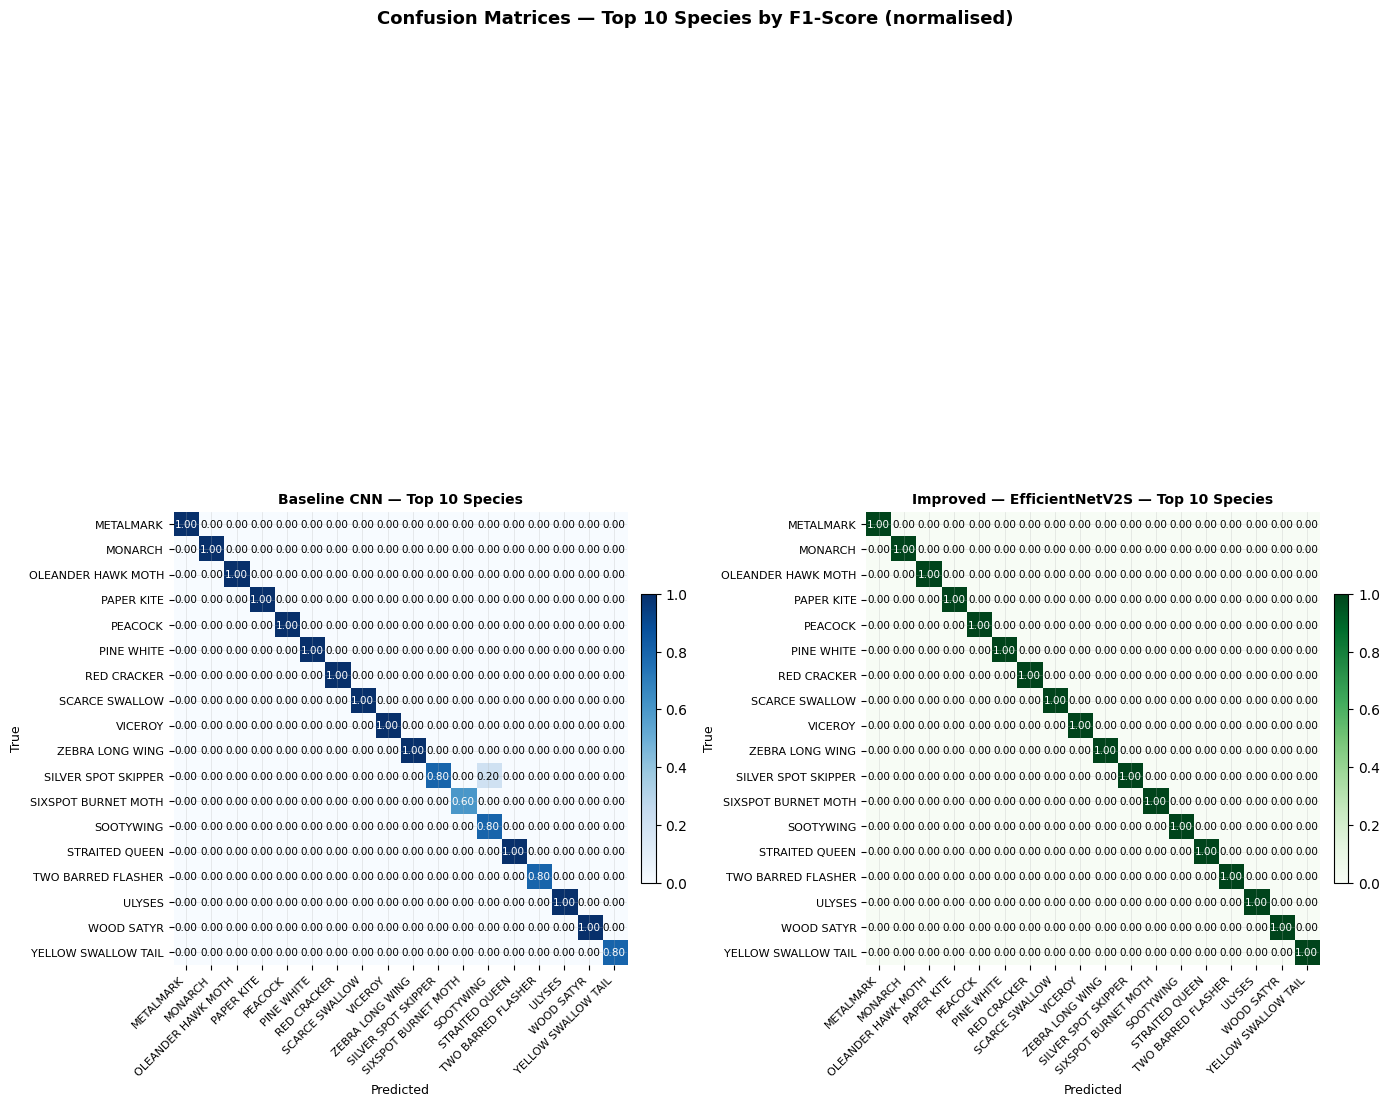

In [32]:
# ── D8. Confusion Matrices ────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

# Reuse best_a / best_b from D6 — top 10 (name, f1) lists
top10_names_a = [name for name, _ in best_a]
top10_names_b = [name for name, _ in best_b]
top10_names   = list(dict.fromkeys(top10_names_a + top10_names_b))  # union, preserve order
top10_indices = [class_names.index(n) for n in top10_names]
n_top         = len(top10_names)

# Build full matrices then normalise, then slice to top-10 rows & columns
cm_full_a = confusion_matrix(yt_a, yp_a, labels=range(num_classes)).astype(float)
cm_full_b = confusion_matrix(yt_b, yp_b, labels=range(num_classes)).astype(float)
cm_full_a /= cm_full_a.sum(axis=1, keepdims=True)
cm_full_b /= cm_full_b.sum(axis=1, keepdims=True)

cm_a = cm_full_a[np.ix_(top10_indices, top10_indices)]
cm_b = cm_full_b[np.ix_(top10_indices, top10_indices)]

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, n_top * 0.65 + 2)))

for ax, cm_n, title, cmap in [
    (axes[0], cm_a, 'Baseline CNN — Top 10 Species',               'Blues'),
    (axes[1], cm_b, 'Improved — EfficientNetV2S — Top 10 Species', 'Greens'),
]:
    im = ax.imshow(cm_n, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(n_top)); ax.set_yticks(range(n_top))
    ax.set_xticklabels(top10_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(top10_names, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('True', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(n_top):
        for j in range(n_top):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    fontsize=7.5, color='white' if cm_n[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

fig.suptitle('Confusion Matrices — Top 10 Species by F1-Score (normalised)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('top10_matrix.png')
plt.show()

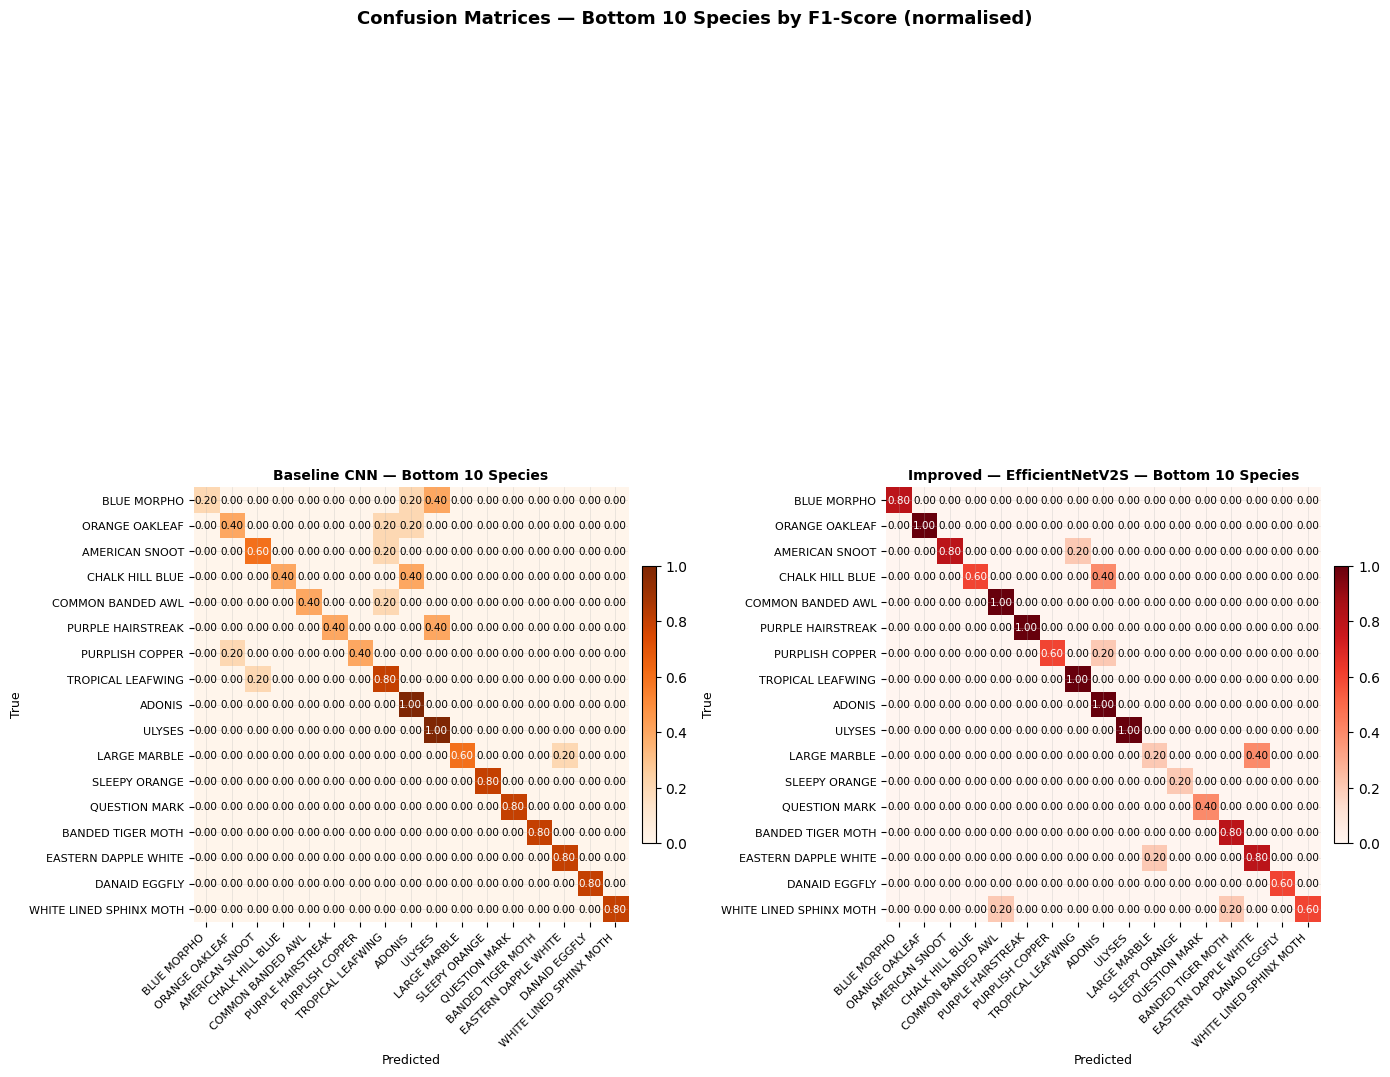

In [33]:
# Bottom 10 by F1 — worst performing species
def bottom10_f1(report, names):
    perf = [(s, report[s]['f1-score']) for s in names if s in report]
    perf.sort(key=lambda x: x[1])
    return perf[:10]  # first 10 = lowest scores

worst_a = bottom10_f1(report_a, class_names)
worst_b = bottom10_f1(report_b, class_names)

bottom10_names_a = [name for name, _ in worst_a]
bottom10_names_b = [name for name, _ in worst_b]
bottom10_names   = list(dict.fromkeys(bottom10_names_a + bottom10_names_b))
bottom10_indices = [class_names.index(n) for n in bottom10_names]
n_bot            = len(bottom10_names)

cm_bot_a = cm_full_a[np.ix_(bottom10_indices, bottom10_indices)]
cm_bot_b = cm_full_b[np.ix_(bottom10_indices, bottom10_indices)]

fig, axes = plt.subplots(1, 2, figsize=(14, max(6, n_bot * 0.65 + 2)))

for ax, cm_n, title, cmap in [
    (axes[0], cm_bot_a, 'Baseline CNN — Bottom 10 Species',               'Oranges'),
    (axes[1], cm_bot_b, 'Improved — EfficientNetV2S — Bottom 10 Species', 'Reds'),
]:
    im = ax.imshow(cm_n, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(n_bot)); ax.set_yticks(range(n_bot))
    ax.set_xticklabels(bottom10_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(bottom10_names, fontsize=8)
    ax.set_xlabel('Predicted', fontsize=9); ax.set_ylabel('True', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(n_bot):
        for j in range(n_bot):
            ax.text(j, i, f'{cm_n[i,j]:.2f}', ha='center', va='center',
                    fontsize=7.5, color='white' if cm_n[i,j] > 0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

fig.suptitle('Confusion Matrices — Bottom 10 Species by F1-Score (normalised)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('worse10_mixups.png')
plt.show()

In [29]:
# ── D9. Final comparison table ────────────────────────────────────────────────
train_a = sum(tf.size(v).numpy() for v in model_a.trainable_weights) / 1e6
train_b = sum(tf.size(v).numpy() for v in model_b.trainable_weights) / 1e6

print('\n' + '='*62)
print(f'  {"Metric":<28} {"Baseline CNN":>14} {"Improved":>14}')
print('  ' + '-'*58)
for label, va, vb in [
    ('Test Accuracy',        f'{acc_a:.4f}',    f'{acc_b:.4f}'),
    ('Test Loss',            f'{loss_a:.4f}',   f'{loss_b:.4f}'),
    ('Val Accuracy (last)',  f'{val_acc_a:.4f}',f'{val_acc_b:.4f}'),
    ('Total params (M)',     f'{params_a:.2f}', f'{params_b:.2f}'),
    ('Trainable params (M)', f'{train_a:.2f}',  f'{train_b:.2f}'),
    ('Accuracy delta',       '',                f'{acc_b-acc_a:+.4f}'),
]:
    print(f'  {label:<28} {va:>14} {vb:>14}')
print('='*62)
if SAVE_FIGS:
    print(f'\n📂 Figures saved to: {base_path}comparison_figs/')


  Metric                         Baseline CNN       Improved
  ----------------------------------------------------------
  Test Accuracy                        0.8580         0.9340
  Test Loss                            0.7481         0.5328
  Val Accuracy (last)                  0.8421         0.9285
  Total params (M)                       1.73          20.68
  Trainable params (M)                   1.73           3.70
  Accuracy delta                                     +0.0760

📂 Figures saved to: /content/drive/MyDrive/Colab Notebooks/pollinators/comparison_figs/


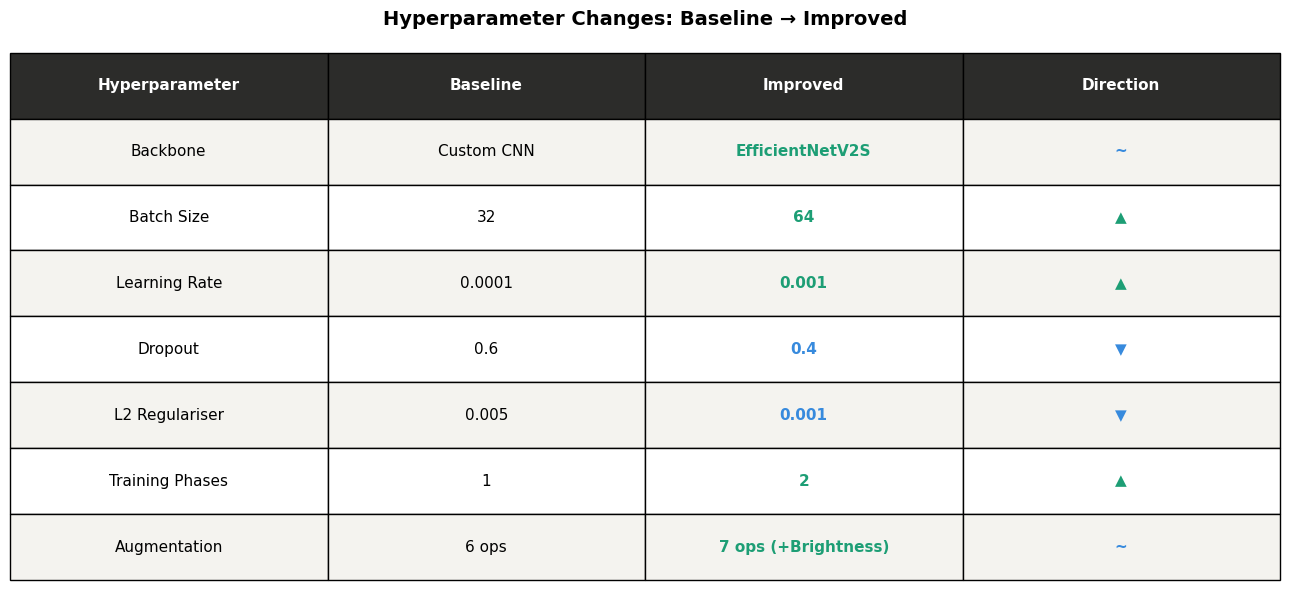

  Test accuracy :  0.8580 → 0.9340  (+0.0760)
  Val accuracy  :  0.8421 → 0.9285  (+0.0864)
  Test loss     :  0.7481 → 0.5328  (-0.2153)
  Parameters    :  1.7M → 20.7M  (12.0×)


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# ── Hyperparameter changes and their measured impact ──────────────────────────
# Fill in your real values after training
changes = [
    {
        'param':       'Backbone',
        'baseline':    'Custom CNN',
        'improved':    'EfficientNetV2S',
        'type':        'categorical',
    },
    {
        'param':       'Batch Size',
        'baseline':    32,
        'improved':    64,
        'type':        'numeric',
    },
    {
        'param':       'Learning Rate',
        'baseline':    0.0001,
        'improved':    0.001,
        'type':        'numeric',
    },
    {
        'param':       'Dropout',
        'baseline':    0.6,
        'improved':    0.4,
        'type':        'numeric',
    },
    {
        'param':       'L2 Regulariser',
        'baseline':    0.005,
        'improved':    0.001,
        'type':        'numeric',
    },
    {
        'param':       'Training Phases',
        'baseline':    1,
        'improved':    2,
        'type':        'numeric',
    },
    {
        'param':       'Augmentation',
        'baseline':    '6 ops',
        'improved':    '7 ops (+Brightness)',
        'type':        'categorical',
    },
]

# ── Real results (pulled from earlier cells) ──────────────────────────────────
acc_delta    = acc_b   - acc_a          # test accuracy improvement
loss_delta   = loss_a  - loss_b         # loss reduction (positive = better)
val_delta    = val_acc_b - val_acc_a    # val accuracy improvement
param_ratio  = params_b / params_a      # how many times more parameters

# ── Plot 1: Hyperparameter change summary table ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis('off')

col_labels = ['Hyperparameter', 'Baseline', 'Improved', 'Direction']
rows = []
for c in changes:
    if c['type'] == 'numeric' and isinstance(c['baseline'], (int, float)):
        direction = '▲' if c['improved'] > c['baseline'] else '▼'
    else:
        direction = '~'
    rows.append([c['param'], str(c['baseline']), str(c['improved']), direction])

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(11)

# Style header
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2C2C2A')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Style rows — highlight changed values
for i, c in enumerate(changes):
    row_idx = i + 1
    for j in range(len(col_labels)):
        table[row_idx, j].set_facecolor('#F4F3EF' if i % 2 == 0 else 'white')

    # Colour the improved value
    if c['type'] == 'numeric' and isinstance(c['baseline'], (int, float)):
        color = '#1D9E75' if c['improved'] > c['baseline'] else '#378ADD'
    else:
        color = '#1D9E75'
    table[row_idx, 2].set_text_props(color=color, fontweight='bold')
    table[row_idx, 3].set_text_props(
        color='#1D9E75' if rows[i][3] == '▲' else '#378ADD', fontweight='bold'
    )

ax.set_title('Hyperparameter Changes: Baseline → Improved',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
savefig('hyperparameters.png')
plt.show()

# ── Summary print ─────────────────────────────────────────────────────────────
print('='*52)
print(f'  Test accuracy :  {acc_a:.4f} → {acc_b:.4f}  ({acc_delta:+.4f})')
print(f'  Val accuracy  :  {val_acc_a:.4f} → {val_acc_b:.4f}  ({val_delta:+.4f})')
print(f'  Test loss     :  {loss_a:.4f} → {loss_b:.4f}  ({-loss_delta:+.4f})')
print(f'  Parameters    :  {params_a:.1f}M → {params_b:.1f}M  ({param_ratio:.1f}×)')
print('='*52)

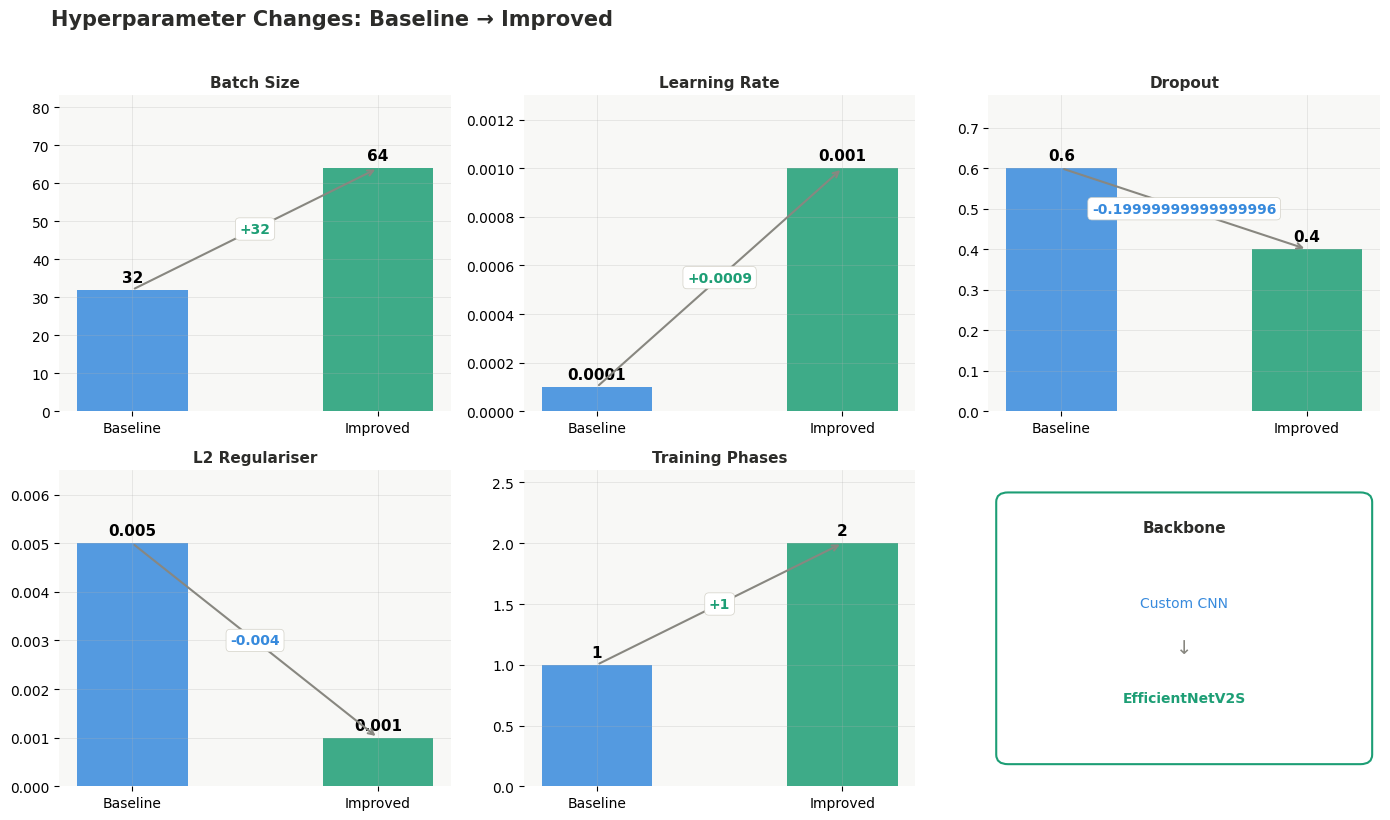

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.patch.set_facecolor('white')
axes = axes.flatten()

# Only numeric changes can be plotted — categorical ones get a special card
numeric = [c for c in changes if c['type'] == 'numeric' and
           isinstance(c['baseline'], (int, float))]
categorical = [c for c in changes if c['type'] == 'categorical']

for ax, c in zip(axes, numeric):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_visible(False)

    vals   = [c['baseline'], c['improved']]
    colors = [BLUE, TEAL]
    bars   = ax.bar(['Baseline', 'Improved'], vals, color=colors,
                    alpha=0.85, width=0.45)

    # Value labels on bars
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                str(v), ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    # Delta arrow + label
    delta  = c['improved'] - c['baseline']
    sign   = '+' if delta > 0 else ''
    dcolor = TEAL if delta > 0 else BLUE
    ax.annotate('', xy=(1, c['improved']), xytext=(0, c['baseline']),
                arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))
    ax.text(0.5, (c['baseline'] + c['improved']) / 2,
            f'{sign}{delta}', ha='center', va='center',
            fontsize=10, fontweight='bold', color=dcolor,
            bbox=dict(fc='white', ec=LGRAY, lw=0.5,
                      boxstyle='round,pad=0.3'))

    ax.set_title(c['param'], fontsize=11, fontweight='bold', color=DARK)
    ax.set_ylim(0, max(vals) * 1.3)
    ax.tick_params(labelsize=10)

# Fill remaining axes with categorical change cards
cat_axes = axes[len(numeric):]
for ax, c in zip(cat_axes, categorical):
    ax.set_facecolor(BG)
    ax.axis('off')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    # Card outline
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.1), 0.9, 0.8,
        boxstyle='round,pad=0.03', fc='white', ec=TEAL, lw=1.5))

    ax.text(0.5, 0.82, c['param'], ha='center', va='center',
            fontsize=11, fontweight='bold', color=DARK)
    ax.text(0.5, 0.58, str(c['baseline']), ha='center', va='center',
            fontsize=10, color=BLUE)
    ax.text(0.5, 0.44, '↓', ha='center', va='center',
            fontsize=14, color=GRAY)
    ax.text(0.5, 0.28, str(c['improved']), ha='center', va='center',
            fontsize=10, color=TEAL, fontweight='bold')

# Hide any completely unused axes
for ax in axes[len(numeric) + len(categorical):]:
    ax.set_visible(False)

fig.suptitle('Hyperparameter Changes: Baseline → Improved',
             fontsize=15, fontweight='bold', color=DARK,
             x=0.04, ha='left', y=1.02)
plt.tight_layout()
savefig('hyperparameters.png')
plt.show()